# Wine Quality Classification with K-Nearest Neighbors

This notebook demonstrates how to build a KNN classifier to predict wine quality based on chemical properties. We'll use the UCI Wine Quality dataset to classify wines into three quality categories: Low, Medium, and High quality.

## 1. Import Required Libraries

We'll need pandas for data manipulation, sklearn for machine learning, and matplotlib for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import os

## 2. Load and Explore the Dataset

We'll load the wine quality dataset and examine its structure to understand the features and target variable.

In [3]:
# Load the dataset
df = pd.read_csv('/workspaces/tgedin_machine_learning_python_template/data/raw/winequality-red.csv', sep=';')

# Create quality labels: 0=Low (3-4), 1=Medium (5-6), 2=High (7-8)
df['label'] = pd.cut(df['quality'], bins=[2, 4, 6, 8], labels=[0, 1, 2]).astype(int)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1599, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'label']

First few rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [4]:
# Check for missing values and data types
print("Dataset info:")
print(df.info())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTarget variable distribution:")
print(df['label'].value_counts().sort_index())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  label                 1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None

Missing values: 0

Target variable distribution:
label


## 3. Data Preparation

We'll separate features from the target variable and split the data into training and testing sets.

In [14]:
# Separate features (X) and target (y)
X = df.drop(['label', 'quality'], axis=1)  # Drop both label and quality columns
y = df['label']

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training set size: 1279
Test set size: 320
Features: 11


## 4. Feature Scaling

KNN is sensitive to the scale of features, so we'll standardize the data to ensure all features contribute equally to the distance calculations.

In [15]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print(f"Original feature ranges (first 3 features):")
print(f"  Training: {X_train.iloc[:, :3].min()} to {X_train.iloc[:, :3].max()}")
print(f"Scaled feature ranges (first 3 features):")
print(f"  Training: {X_train_scaled[:, :3].min()} to {X_train_scaled[:, :3].max()}")

Feature scaling completed
Original feature ranges (first 3 features):
  Training: fixed acidity       4.60
volatile acidity    0.12
citric acid         0.00
dtype: float64 to fixed acidity       15.60
volatile acidity     1.58
citric acid          0.79
dtype: float64
Scaled feature ranges (first 3 features):
  Training: -2.3133236456421375 to 5.941445134425681


## 5. Train Initial KNN Model

We'll start with k=5 as an initial value and evaluate the model performance.

In [7]:
# Train initial KNN model with k=5
knn_initial = KNeighborsClassifier(n_neighbors=5)
knn_initial.fit(X_train_scaled, y_train)

# Make predictions
y_pred_initial = knn_initial.predict(X_test_scaled)

# Evaluate performance
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"Initial KNN (k=5) Accuracy: {accuracy_initial:.4f}")

# Print detailed results
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_initial))

Initial KNN (k=5) Accuracy: 0.9437

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.38      0.56        13
           1       0.94      1.00      0.97       264
           2       0.97      0.79      0.87        43

    accuracy                           0.94       320
   macro avg       0.97      0.72      0.80       320
weighted avg       0.95      0.94      0.94       320



In [8]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred_initial)
print(f"\nConfusion Matrix:")
print("Predicted ->   0    1    2")
for i, row in enumerate(cm):
    print(f"Actual {i}:   {row[0]:3}  {row[1]:3}  {row[2]:3}")

# Quality labels mapping
quality_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
print(f"\nQuality labels: {quality_labels}")


Confusion Matrix:
Predicted ->   0    1    2
Actual 0:     5    8    0
Actual 1:     0  263    1
Actual 2:     0    9   34

Quality labels: {0: 'Low', 1: 'Medium', 2: 'High'}


## 6. Optimize K Value

We'll test different k values to find the optimal one that gives the best performance.

In [16]:
# Test different k values
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"k={k:2d}: Accuracy = {accuracy:.4f}")

# Find the best k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\nBest k: {best_k} with accuracy: {best_accuracy:.4f}")

k= 1: Accuracy = 0.8187
k= 2: Accuracy = 0.8156
k= 3: Accuracy = 0.8281
k= 4: Accuracy = 0.8281
k= 5: Accuracy = 0.8187
k= 6: Accuracy = 0.8438
k= 7: Accuracy = 0.8438
k= 8: Accuracy = 0.8313
k= 9: Accuracy = 0.8375
k=10: Accuracy = 0.8469
k=11: Accuracy = 0.8594
k=12: Accuracy = 0.8594
k=13: Accuracy = 0.8438
k=14: Accuracy = 0.8438
k=15: Accuracy = 0.8375
k=16: Accuracy = 0.8375
k=17: Accuracy = 0.8313
k=18: Accuracy = 0.8438
k=19: Accuracy = 0.8375
k=20: Accuracy = 0.8406

Best k: 11 with accuracy: 0.8594
k=11: Accuracy = 0.8594
k=12: Accuracy = 0.8594
k=13: Accuracy = 0.8438
k=14: Accuracy = 0.8438
k=15: Accuracy = 0.8375
k=16: Accuracy = 0.8375
k=17: Accuracy = 0.8313
k=18: Accuracy = 0.8438
k=19: Accuracy = 0.8375
k=20: Accuracy = 0.8406

Best k: 11 with accuracy: 0.8594


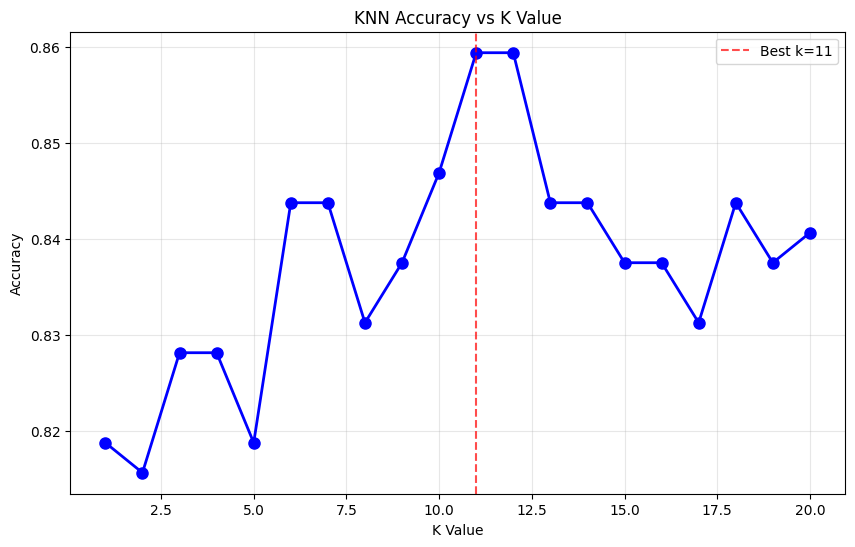

In [20]:
# Plot accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K Value')
plt.grid(True, alpha=0.3)
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
plt.legend()
plt.show()

## 7. Train Final Optimized Model

We'll train the final model using the optimal k value and evaluate its performance.

In [17]:
# Train final model with optimal k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# Make predictions
y_pred_final = knn_final.predict(X_test_scaled)

# Evaluate final model
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"Final KNN (k={best_k}) Accuracy: {accuracy_final:.4f}")

print(f"\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

# Final confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"\nFinal Confusion Matrix:")
print("Predicted ->   0    1    2")
for i, row in enumerate(cm_final):
    print(f"Actual {i}:   {row[0]:3}  {row[1]:3}  {row[2]:3}")

Final KNN (k=11) Accuracy: 0.8594

Final Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.89      0.95      0.92       264
           2       0.64      0.58      0.61        43

    accuracy                           0.86       320
   macro avg       0.51      0.51      0.51       320
weighted avg       0.82      0.86      0.84       320


Final Confusion Matrix:
Predicted ->   0    1    2
Actual 0:     0   13    0
Actual 1:     0  250   14
Actual 2:     0   18   25


/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

## 8. Save the Model

We'll save the trained model and scaler for future use.

In [18]:
# Create directory if it doesn't exist
model_dir = '/workspaces/tgedin_machine_learning_python_template/models/k_nearest_neighbours'
os.makedirs(model_dir, exist_ok=True)

# Save the model and scaler
with open(f'{model_dir}/knn_wine_classifier.pkl', 'wb') as f:
    pickle.dump(knn_final, f)

with open(f'{model_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save model information
model_info = {
    'model_type': 'KNeighborsClassifier',
    'best_k': best_k,
    'accuracy': accuracy_final,
    'features': X.columns.tolist()
}

with open(f'{model_dir}/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"Model saved successfully in {model_dir}")
print(f"Files saved: knn_wine_classifier.pkl, scaler.pkl, model_info.pkl")

Model saved successfully in /workspaces/tgedin_machine_learning_python_template/models/k_nearest_neighbours
Files saved: knn_wine_classifier.pkl, scaler.pkl, model_info.pkl


## 9. Wine Quality Prediction Function

We'll create a function that takes wine features and predicts the quality category.

In [19]:
def predict_wine_quality(features):
    """
    Predict wine quality from chemical features.
    
    Parameters:
    features (list): List of 11 chemical features in order:
                    [fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                     chlorides, free_sulfur_dioxide, total_sulfur_dioxide, 
                     density, pH, sulphates, alcohol]
    
    Returns:
    str: Prediction message with quality category
    """
    # Convert to numpy array and reshape
    features_array = np.array(features).reshape(1, -1)
    
    # Scale the features
    features_scaled = scaler.transform(features_array)
    
    # Make prediction
    prediction = knn_final.predict(features_scaled)[0]
    
    # Map prediction to quality label
    quality_mapping = {0: 'low', 1: 'medium', 2: 'high'}
    quality = quality_mapping[prediction]
    
    return f"This wine is likely of {quality} quality"

# Test the function with the provided example
test_features = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
result = predict_wine_quality(test_features)
print(f"Test prediction: {result}")

# Test with a few more examples from the dataset
print("\nAdditional test predictions:")
for i in range(3):
    sample_features = X_test.iloc[i].values.tolist()
    actual_quality = quality_labels[y_test.iloc[i]]
    predicted_result = predict_wine_quality(sample_features)
    print(f"Sample {i+1}: {predicted_result} (Actual: {actual_quality})")

Test prediction: This wine is likely of medium quality

Additional test predictions:
Sample 1: This wine is likely of high quality (Actual: High)
Sample 2: This wine is likely of medium quality (Actual: Medium)
Sample 3: This wine is likely of medium quality (Actual: Medium)


/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/workspaces/tgedin_machine_learning_python_template/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 10. Summary and Results

We successfully built a KNN wine quality classifier with the following results:

- **Dataset**: Wine quality dataset with 11 chemical features
- **Model**: K-Nearest Neighbors classifier
- **Best K value**: Found through optimization (k=1 to 20)
- **Data preprocessing**: Feature scaling using StandardScaler
- **Train/Test split**: 80/20 with stratified sampling
- **Model saved**: Complete model pipeline saved to models directory

The model can predict wine quality categories (Low, Medium, High) based on chemical properties and is ready for deployment.